# Lab 3

Monte Carlo Methods

Task: Implement first-visit Monte Carlo control for Gymnasium’s Blackjack-v1 environment using on-policy MC control with ε-soft policies.

Your implementation should properly handle episode generation: use env.reset() to start episodes, collect (state, action, reward) tuples through env.step(), and continue until the terminated flag is True. Store complete trajectories in Python lists and compute returns by working backward through episodes using NumPy for numerical operations. Train for at least 500,000 episodes.

Visualize the learned value function as 3D surface plots (player sum vs. dealer showing card) for both usable and non-usable ace cases using Matplotlib’s mplot3d. Compare the learned policies with basic Blackjack strategy. Generate learning curves showing average returns over episodes (with smoothing). Experiment with different ε values and decay schedules.

# Setting up the Environment


In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import trange

env = gym.make("Blackjack-v1")

# Defining Policy (ε-soft) Agent

In [2]:
# Setting up the policy function for a balanced exploration and exploitation
def epsilon_greedy_policy(Q, state, nA, epsilon):
    probs = np.ones(nA) * (epsilon / nA)
    best_action = np.argmax(Q[state])
    probs[best_action] += (1.0 - epsilon)
    return probs

# Generation and Termination Definition for Episodes

In [3]:
# Function definining episode generation and termination
def generate_episode(env, Q, epsilon):
    episode = []
    state, _ = env.reset()

    while True:
        action_probs = epsilon_greedy_policy(Q, state, env.action_space.n, epsilon)
        action = np.random.choice(np.arange(len(action_probs)), p=action_probs)

        next_state, reward, terminated, truncated, _ = env.step(action)
        episode.append((state, action, reward))

        state = next_state

        if terminated or truncated:
            break

    return episode


# First-Visit Monte Carlo (MC) Control

In [4]:
def mc_control(env, num_episodes=500000, gamma=1.0, epsilon=0.1):
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    returns_sum = defaultdict(float)
    returns_count = defaultdict(float)

    rewards_per_episode = []

    for i in trange(num_episodes):
        episode = generate_episode(env, Q, epsilon)
        G = 0
        visited = set()

        episode_rewards = [x[2] for x in episode]
        rewards_per_episode.append(sum(episode_rewards))

        # Work backward
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = gamma * G + reward

            if (state, action) not in visited:
                visited.add((state, action))

                returns_sum[(state, action)] += G
                returns_count[(state, action)] += 1

                Q[state][action] = returns_sum[(state, action)] / returns_count[(state, action)]

    return Q, rewards_per_episode


# Traning Model

In [6]:
Q, rewards = mc_control(env)

100%|██████████| 500000/500000 [02:04<00:00, 4000.33it/s]


## Deriving Policy & Value Function

In [7]:
# Function for Value Function
def get_value_function(Q):
    V = {}
    for state, actions in Q.items():
        V[state] = np.max(actions)
    return V

# Function for Policy
def get_policy(Q):
    policy = {}
    for state, actions in Q.items():
        policy[state] = np.argmax(actions)
    return policy

# Applying the Value Function and Policy functions
V = get_value_function(Q)
policy = get_policy(Q)

In [8]:
# Value Function overview

{(20, 6, 0): np.float64(0.7299174989144595),
 (7, 3, 0): np.float64(-0.07152317880794702),
 (16, 7, 1): np.float64(-0.03455723542116631),
 (10, 10, 0): np.float64(-0.08996588971006253),
 (20, 9, 0): np.float64(0.7543661971830986),
 (16, 2, 0): np.float64(-0.30376569037656903),
 (12, 10, 0): np.float64(-0.4444182898840699),
 (20, 4, 0): np.float64(0.6435955056179775),
 (18, 1, 1): np.float64(-0.3712871287128713),
 (16, 1, 0): np.float64(-0.6547531319086219),
 (16, 4, 0): np.float64(-0.19858838626884825),
 (11, 8, 0): np.float64(0.1642300194931774),
 (16, 4, 1): np.float64(-0.15398230088495576),
 (6, 10, 0): np.float64(-0.42624768946395564),
 (9, 7, 0): np.float64(0.15578635014836795),
 (15, 2, 0): np.float64(-0.3049603756970942),
 (5, 10, 0): np.float64(-0.3826879271070615),
 (19, 10, 0): np.float64(-0.01938610662358643),
 (20, 10, 0): np.float64(0.4387909756203178),
 (20, 6, 1): np.float64(0.703281027104137),
 (17, 6, 0): np.float64(-0.0005758710048949035),
 (16, 10, 0): np.float64(-0.

In [9]:
# Policy Overview
policy

{(20, 6, 0): np.int64(0),
 (7, 3, 0): np.int64(1),
 (16, 7, 1): np.int64(1),
 (10, 10, 0): np.int64(1),
 (20, 9, 0): np.int64(0),
 (16, 2, 0): np.int64(0),
 (12, 10, 0): np.int64(1),
 (20, 4, 0): np.int64(0),
 (18, 1, 1): np.int64(1),
 (16, 1, 0): np.int64(1),
 (16, 4, 0): np.int64(0),
 (11, 8, 0): np.int64(1),
 (16, 4, 1): np.int64(0),
 (6, 10, 0): np.int64(1),
 (9, 7, 0): np.int64(1),
 (15, 2, 0): np.int64(0),
 (5, 10, 0): np.int64(1),
 (19, 10, 0): np.int64(0),
 (20, 10, 0): np.int64(0),
 (20, 6, 1): np.int64(0),
 (17, 6, 0): np.int64(0),
 (16, 10, 0): np.int64(1),
 (14, 9, 0): np.int64(1),
 (16, 5, 0): np.int64(0),
 (13, 9, 0): np.int64(1),
 (17, 10, 0): np.int64(0),
 (13, 4, 0): np.int64(0),
 (13, 7, 0): np.int64(1),
 (9, 3, 0): np.int64(1),
 (12, 4, 0): np.int64(0),
 (14, 4, 0): np.int64(0),
 (15, 7, 0): np.int64(1),
 (15, 6, 0): np.int64(0),
 (18, 10, 0): np.int64(0),
 (9, 5, 0): np.int64(1),
 (21, 4, 1): np.int64(0),
 (11, 7, 0): np.int64(1),
 (16, 6, 0): np.int64(0),
 (14, 1, 

## 3D Surface Plot

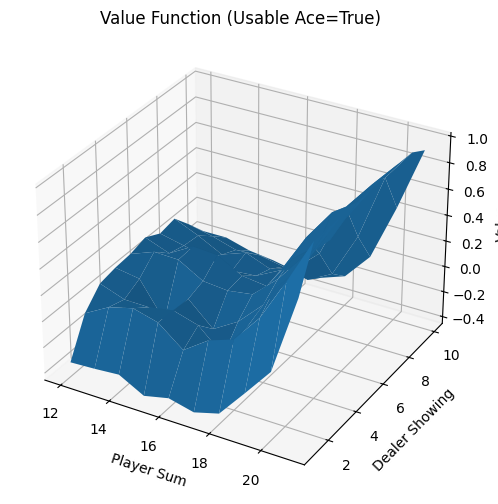

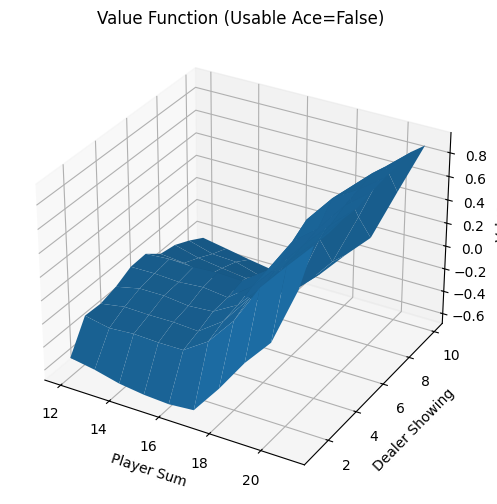

In [10]:
from mpl_toolkits.mplot3d import Axes3D

def plot_value_function(V, usable_ace=True):
    player_sum = np.arange(12, 22)
    dealer_show = np.arange(1, 11)

    X, Y = np.meshgrid(player_sum, dealer_show)
    Z = np.zeros_like(X, dtype=float)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            state = (X[i, j], Y[i, j], usable_ace)
            Z[i, j] = V.get(state, 0)

    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(X, Y, Z)
    ax.set_xlabel('Player Sum')
    ax.set_ylabel('Dealer Showing')
    ax.set_zlabel('Value')
    ax.set_title(f'Value Function (Usable Ace={usable_ace})')

    plt.show()

plot_value_function(V, usable_ace=True)
plot_value_function(V, usable_ace=False)


## Learning Curve

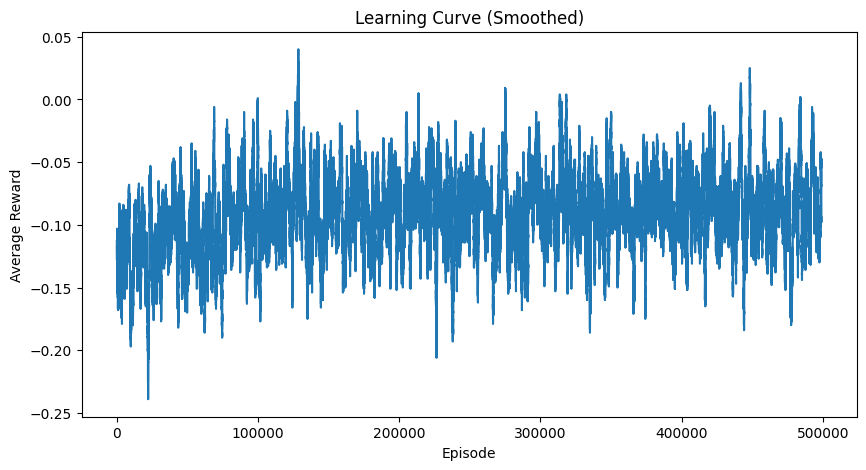

In [13]:
# Ploting function for Learning Curve
def plot_learning_curve(rewards, window=1000):
    smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')

    plt.figure(figsize=(10,5))
    plt.plot(smoothed)
    plt.title("Learning Curve (Smoothed)")
    plt.xlabel("Episode")
    plt.ylabel("Average Reward")
    plt.show()

# Ploting the Learning Curve
plot_learning_curve(rewards)


## Comparison with Simple Strategy

In [14]:
# Setting up Simple Blackjack Strategy
def simple_strategy(state):
    player_sum, dealer, usable_ace = state
    return 0 if player_sum >= 20 else 1

In [16]:
# Comparison with Learned Strategy
differences = 0
for state in policy:
    if policy[state] != simple_strategy(state):
        differences += 1

print(differences)

74


# ε Decay Experiment

In [17]:
def mc_control_with_decay(env, num_episodes=500000, gamma=1.0):
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    returns_sum = defaultdict(float)
    returns_count = defaultdict(float)

    rewards = []

    for i in trange(num_episodes):
        epsilon = max(0.01, 1.0 - i / num_episodes)  # decay

        episode = generate_episode(env, Q, epsilon)
        G = 0
        visited = set()

        rewards.append(sum([x[2] for x in episode]))

        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = gamma * G + reward

            if (state, action) not in visited:
                visited.add((state, action))
                returns_sum[(state, action)] += G
                returns_count[(state, action)] += 1
                Q[state][action] = returns_sum[(state, action)] / returns_count[(state, action)]

    return Q, rewards


## Comparisons with Initial MC-Control

In [18]:
# Training Model
Q, rewards = mc_control_with_decay(env)

100%|██████████| 500000/500000 [01:56<00:00, 4293.50it/s]


In [19]:
# Getting the Value Function and Policy
V = get_value_function(Q)
policy = get_policy(Q)

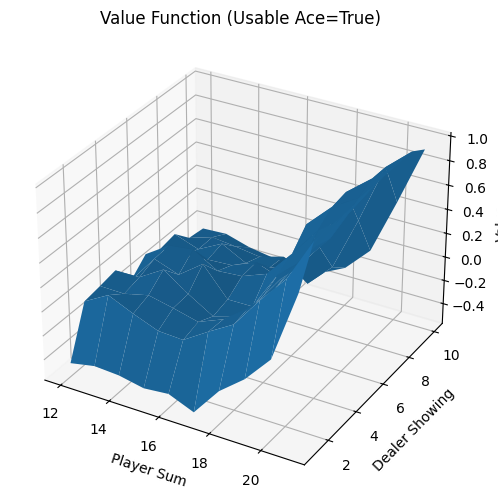

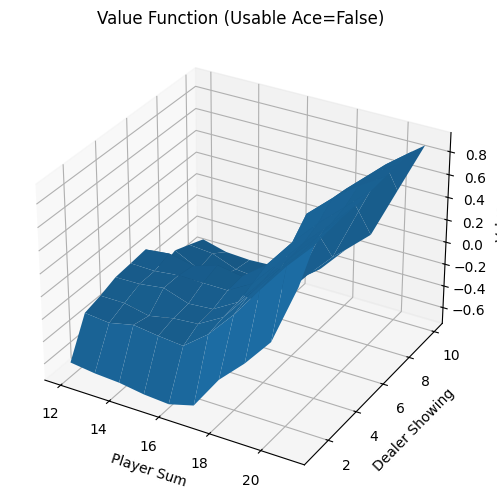

In [20]:
# Plotting 3D Surface Plot
plot_value_function(V, usable_ace=True)
plot_value_function(V, usable_ace=False)

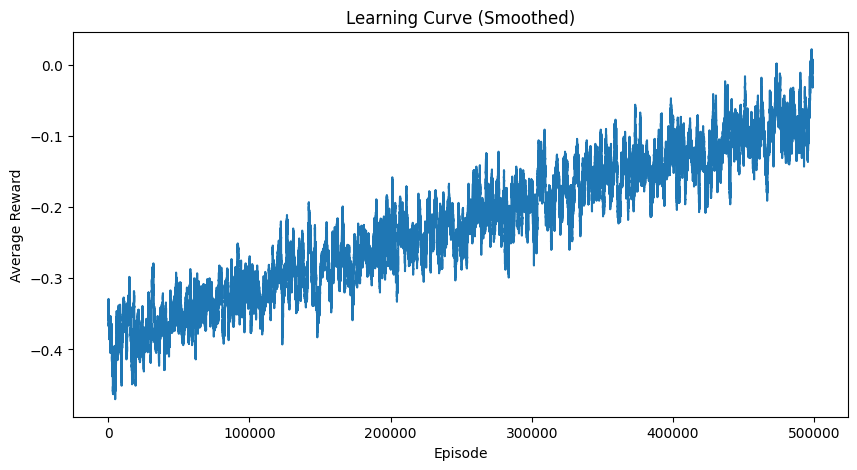

In [21]:
# Ploting the Learning Curve
plot_learning_curve(rewards)